<a href="https://colab.research.google.com/github/louis23/chinese-digits-classification/blob/louiswang/Chinese_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Wang XiangLin (23A475R)

# Introduction
## In this problem, we aim to develop a fully connected feedforward neural network which can predict, for any given image with a handwritten Chinese character, what that character really is.

## There might not be a real life practical use case for this model as it only tests for and predicts single chinese characters. Hence it might just be a proof of concept, to show that the model is able to predict with high accuracy.

## Dataset
The dataset is from Kaggle (https://www.kaggle.com/datasets/fedesoriano/chinese-mnist-digit-recognizer/data), which contains data of 15000 images of random Chinese numeral characters from 15 categories. Later on, after doing some EDA, I will find out that the resolution of the images are 64 x 64 pixels and the dataset has been flattened to linear shape of 4096 values.

# Exploratory Data Analysis

In [ ]:
#import libraries
import numpy as np
import tensorflow.keras as keras
from matplotlib import pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


## Importing dataset (uploaded to Google Drive after downloading from Kaggle)

In [ ]:
import pandas as pd
dataset = pd.read_csv("/content/drive/MyDrive/NYP SDAAI/ITI106 Foundations of Deep Learning/Assignment/chineseMNIST.csv")
dataset

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,label,character
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9,九
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9,九
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9,九
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9,九
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,9,九
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,8,八
14996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,8,八
14997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,8,八
14998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,8,八


The dataset has 4098 columns. The first 4096 columns represent the 4096 pixels of each individual image. The second last column 'label' displays the character in numerals, while the last column 'character' shows the actual chinese character that was written in the image.

In [ ]:
dataset['character'].value_counts()

九    1000
十    1000
百    1000
千    1000
万    1000
亿    1000
零    1000
一    1000
二    1000
三    1000
四    1000
五    1000
六    1000
七    1000
八    1000
Name: character, dtype: int64

From above, we can see that there are 15 chinese numeral characters.

In [ ]:
dataset['label'].value_counts()

9            1000
10           1000
100          1000
1000         1000
10000        1000
100000000    1000
0            1000
1            1000
2            1000
3            1000
4            1000
5            1000
6            1000
7            1000
8            1000
Name: label, dtype: int64

In [ ]:
null_values = dataset.isnull().sum().sum()
print(null_values)

0


The dataset has no null values. Each chinese numeral character has 1000 values. The 15 categories are zero to nine, ten, hundred, thousand, ten thousand and hundred million.

# Label Encoding
I will encode my own labels on the chinese characters and store them in a new column.

In [ ]:
# Define the custom mapping dictionary
custom_mapping = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 100: 11, 1000: 12, 10000: 13, 100000000: 14}

# Apply the custom mapping to create the new encoded column
dataset['Encoded_Label'] = dataset['label'].map(custom_mapping)


In [ ]:
#Shuffle data
dataset_shuffled = dataset.sample(frac=1, random_state=0)

#split the shuffled dataset into explanation data and target data.
x = dataset_shuffled.iloc[:,0:4096]
y = dataset_shuffled.iloc[:,[4098]]

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2) # Split 80% for training set
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5) # Split the remaining to 10% for validation and 10% for testing set

In [ ]:
print(len(x_train))
print(len(y_train))
print(len(x_test))
print(len(y_test))
print(len(x_val))
print(len(y_val))


12000
12000
1500
1500
1500
1500


Dataset is shuffled, then split into input data (x) and output labels (y), which is the new encoded_label column created. The data is then split into train, test and validation sets with a 80/10/10 ratio.

In [ ]:
print("Min value of pixel:", x.values.min())
print("Max value of pixel:", x.values.max())

Min value of pixel: 0
Max value of pixel: 255


I have checked the values of x, which reflect the intensity of each pixel. Normally the values range from 0 (black) to 255 (white), which is true as shown above. There are no RGB color channels as there is only 1 column of values.

In [ ]:
# #normalizes data from 0 to 1
x_train_scaled = x_train/255
x_val_scaled = x_val/255
x_test_scaled = x_test/255

From the above, it can be deduced that each pixel has a value that ranges from 0 to 255. To work with small values for neural networks, let's scale the values to between 0.0 and 1.0

In [ ]:
print("x_train_scaled", x_train_scaled.shape)
print("x_val_scaled", x_val_scaled.shape)
print("x_test_scaled", x_test_scaled.shape)
print("y_train", y_train.shape)
print("y_val", y_val.shape)
print("y_test", y_test.shape)

x_train_scaled (12000, 4096)
x_val_scaled (1500, 4096)
x_test_scaled (1500, 4096)
y_train (12000, 1)
y_val (1500, 1)
y_test (1500, 1)


The input data consists of 12000 training images, 1500 validation and 1500 test images.

In [ ]:
# Preview the first character
first_row = x_train_scaled.iloc[0]

# Reshape the row into a 64 by 64 array
reshaped_array = np.array(first_row).reshape(64, 64)

# Adjust the display settings
np.set_printoptions(threshold=np.prod(reshaped_array.shape))

# Output the reshaped array
print(reshaped_array)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.     

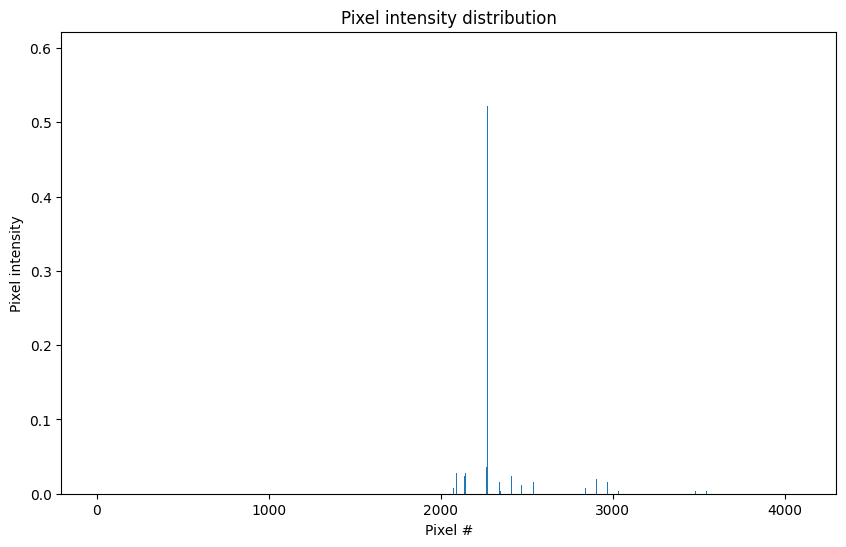

In [ ]:
random_row = x_train_scaled.iloc[0]

# Convert the row to a list for plotting
values_list = random_row.values.tolist()

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(values_list)), values_list)
plt.xlabel('Pixel #')
plt.ylabel('Pixel intensity')
plt.title('Pixel intensity distribution')
plt.show()

The above plot shows that the x values have been normalized successfully and range from 0 to 1.

Let's take a look at some sample images, to confirm if each image is 64 x 64 pixels.

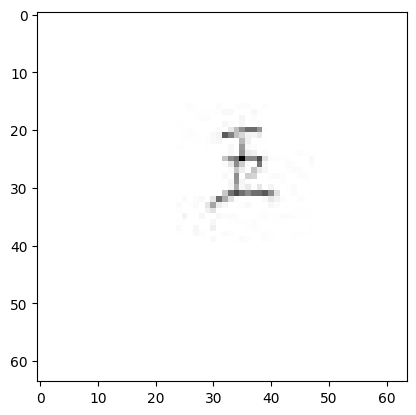

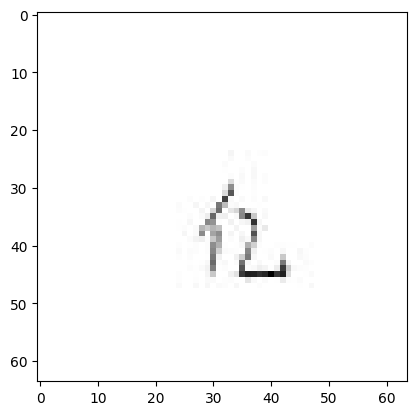

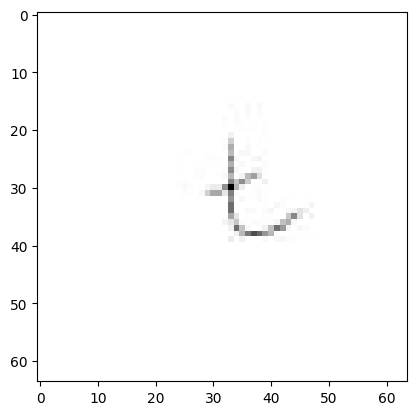

In [ ]:
#import numpy and give a seed.
import numpy as np
np.random.seed(31)
#Show 3 letter at random and convert them into gray scale letters.
for i in range(3):
    plt.imshow(x_train_scaled.iloc[np.random.randint(0,15000)].values.reshape(64,64),cmap='Greys')
    plt.show()

Yep, the characters look alright in chinese. Hence 64 x 64 is correct.

# Building the model

In [ ]:
# Create a Sequential Model
model = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu'))
# Add another Dense layer to serve as the output layer
model.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

In [ ]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               524416    
                                                                 
 dense_1 (Dense)             (None, 15)                1935      
                                                                 
Total params: 526351 (2.01 MB)
Trainable params: 526351 (2.01 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [ ]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
model.save_weights("initial_weights.chk")

In [ ]:
history = model.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val))


Epoch 1/30
375/375 [==============================] - 5s 10ms/step - loss: 1.9834 - accuracy: 0.4119 - val_loss: 1.5815 - val_accuracy: 0.5440
Epoch 2/30
375/375 [==============================] - 4s 9ms/step - loss: 1.2863 - accuracy: 0.6380 - val_loss: 1.2182 - val_accuracy: 0.6400
Epoch 3/30
375/375 [==============================] - 4s 10ms/step - loss: 0.9195 - accuracy: 0.7479 - val_loss: 0.9978 - val_accuracy: 0.7133
Epoch 4/30
375/375 [==============================] - 5s 13ms/step - loss: 0.6978 - accuracy: 0.8110 - val_loss: 0.8821 - val_accuracy: 0.7420
Epoch 5/30
375/375 [==============================] - 4s 10ms/step - loss: 0.5525 - accuracy: 0.8536 - val_loss: 0.7864 - val_accuracy: 0.7627
Epoch 6/30
375/375 [==============================] - 3s 9ms/step - loss: 0.4449 - accuracy: 0.8876 - val_loss: 0.7473 - val_accuracy: 0.7673
Epoch 7/30
375/375 [==============================] - 3s 9ms/step - loss: 0.3661 - accuracy: 0.9094 - val_loss: 0.7126 - val_accuracy: 0.7753
Ep

In [ ]:
model.save('model1.keras')

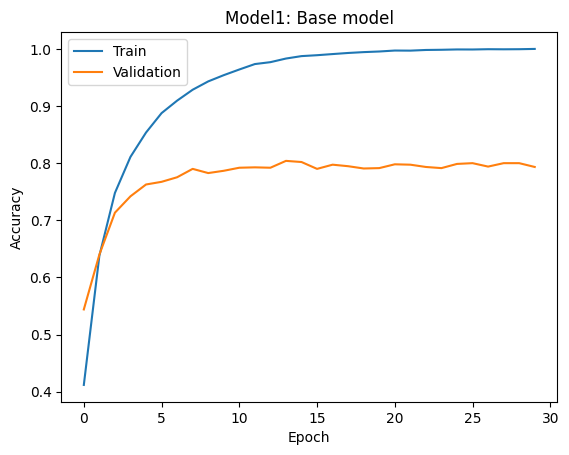

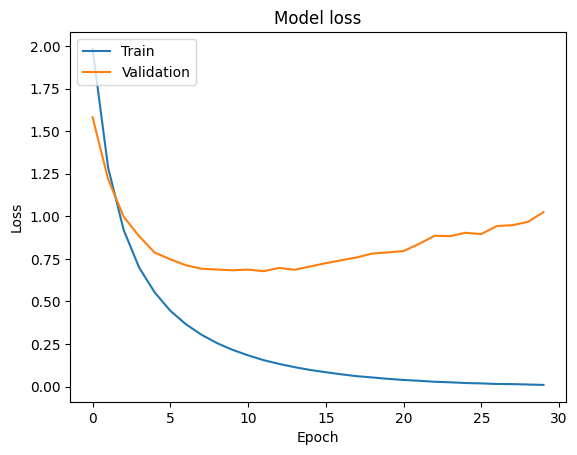

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model1: Base model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

From the above plot, it seems like the model is overfitting at around epoch 9, afterwhich the loss starts to increase. This could be a sign of overfitting, which I will address later. But first I will try a variation of the first model, and add a second hidden layer, also with 128 neurons.

In [ ]:
# Create a Sequential Model
model2 = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model2.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu')) #128 = 128 outputs
# Add a second Dense layer
model2.add(keras.layers.Dense(128, activation='relu'))
# Add another Dense layer to serve as the output layer
model2.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

model2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model2.save_weights("initial_weights.chk")

history2 = model2.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val))



Epoch 1/30
375/375 [==============================] - 5s 13ms/step - loss: 1.7521 - accuracy: 0.4582 - val_loss: 1.1536 - val_accuracy: 0.6373
Epoch 2/30
375/375 [==============================] - 5s 13ms/step - loss: 0.8277 - accuracy: 0.7480 - val_loss: 0.7698 - val_accuracy: 0.7533
Epoch 3/30
375/375 [==============================] - 3s 9ms/step - loss: 0.5079 - accuracy: 0.8400 - val_loss: 0.6376 - val_accuracy: 0.7947
Epoch 4/30
375/375 [==============================] - 3s 9ms/step - loss: 0.3361 - accuracy: 0.8977 - val_loss: 0.5876 - val_accuracy: 0.8047
Epoch 5/30
375/375 [==============================] - 4s 11ms/step - loss: 0.2305 - accuracy: 0.9314 - val_loss: 0.6017 - val_accuracy: 0.8107
Epoch 6/30
375/375 [==============================] - 6s 16ms/step - loss: 0.1649 - accuracy: 0.9535 - val_loss: 0.5533 - val_accuracy: 0.8387
Epoch 7/30
375/375 [==============================] - 6s 16ms/step - loss: 0.1163 - accuracy: 0.9695 - val_loss: 0.5921 - val_accuracy: 0.8267
E

In [ ]:
model.save('model2.keras')

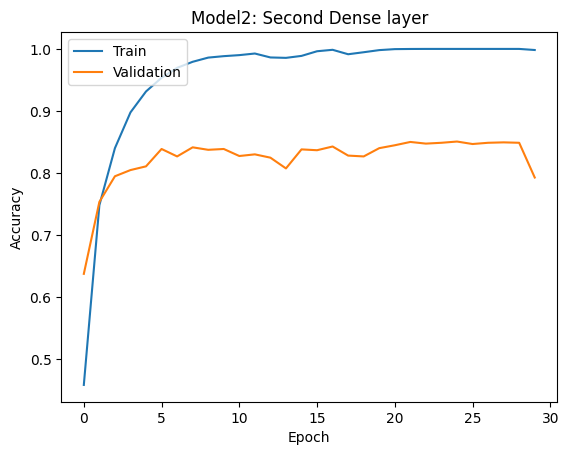

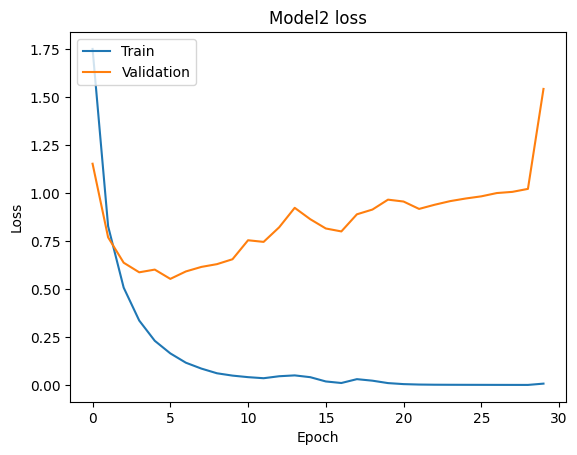

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


# Plot training & validation accuracy values
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model2: Second Dense layer')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model2 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Accuracy has improved in Model 2. Loss also increased from epoch 5 onwards, indicating overfitting. Now I will play around with the network infrastructure and add a second Dense layer with half the neurons.

In [ ]:
# Create a Sequential Model
model2a = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model2a.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu')) #128 = 128 outputs
# Add a second Dense layer
model2a.add(keras.layers.Dense(64, activation='relu'))
# Add a third Dense layer
model2a.add(keras.layers.Dense(64, activation='relu'))

# Add another Dense layer to serve as the output layer
model2a.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

model2a.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model2a.save_weights("initial_weights.chk")

history2a = model2a.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val))



Epoch 1/30
375/375 [==============================] - 6s 14ms/step - loss: 1.7767 - accuracy: 0.4405 - val_loss: 1.1443 - val_accuracy: 0.6327
Epoch 2/30
375/375 [==============================] - 4s 11ms/step - loss: 0.8169 - accuracy: 0.7371 - val_loss: 0.7121 - val_accuracy: 0.7753
Epoch 3/30
375/375 [==============================] - 3s 9ms/step - loss: 0.4836 - accuracy: 0.8383 - val_loss: 0.6200 - val_accuracy: 0.7920
Epoch 4/30
375/375 [==============================] - 3s 9ms/step - loss: 0.3165 - accuracy: 0.8917 - val_loss: 0.6001 - val_accuracy: 0.8007
Epoch 5/30
375/375 [==============================] - 4s 10ms/step - loss: 0.2110 - accuracy: 0.9321 - val_loss: 0.6580 - val_accuracy: 0.7887
Epoch 6/30
375/375 [==============================] - 5s 13ms/step - loss: 0.1511 - accuracy: 0.9539 - val_loss: 0.6414 - val_accuracy: 0.8273
Epoch 7/30
375/375 [==============================] - 3s 9ms/step - loss: 0.1098 - accuracy: 0.9664 - val_loss: 0.6432 - val_accuracy: 0.8273
Ep

In [ ]:
model.save('model2a.keras')

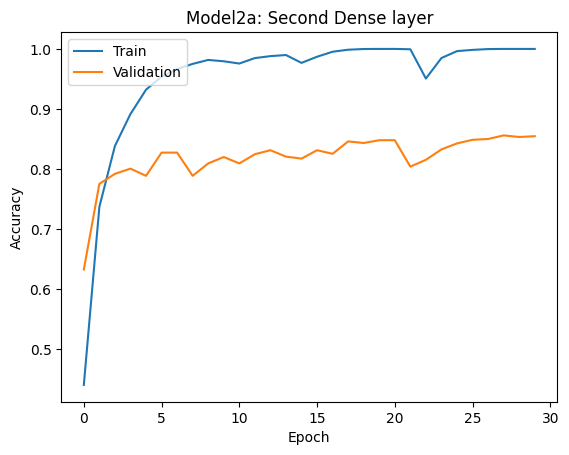

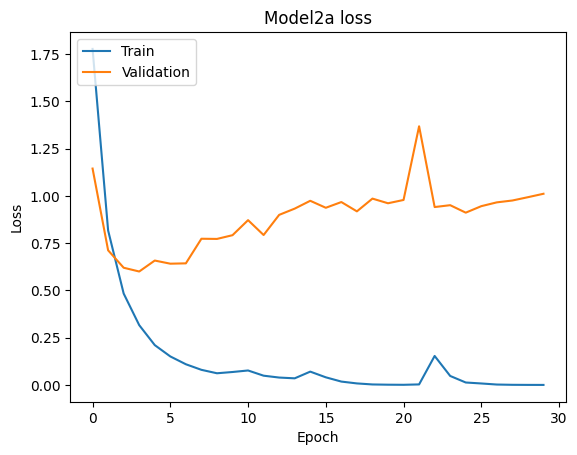

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


# Plot training & validation accuracy values
plt.plot(history2a.history['accuracy'])
plt.plot(history2a.history['val_accuracy'])
plt.title('Model2a: Second Dense layer')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.plot(history2a.history['loss'])
plt.plot(history2a.history['val_loss'])
plt.title('Model2a loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Accuracy seems to have further improved, albeit slightly in Model 2a. Next, we see how we can use regularizers to manage overfitting.

# Regularization to manage overfitting


In [ ]:
# Create a Sequential Model
model2a_earlystop = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model2a_earlystop.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu')) #128 = 128 outputs
# Add a second Dense layer
model2a_earlystop.add(keras.layers.Dense(64, activation='relu'))
# Add a third Dense layer
model2a_earlystop.add(keras.layers.Dense(64, activation='relu'))

# Add another Dense layer to serve as the output layer
model2a_earlystop.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

model2a_earlystop.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min', restore_best_weights=True)

model2a_earlystop.save_weights("initial_weights.chk")

history2a_earlystop = model2a_earlystop.fit(x_train_scaled, y_train, epochs=50, validation_data=(x_val_scaled, y_val), callbacks=[early_stopping])





Epoch 1/50
375/375 [==============================] - 5s 10ms/step - loss: 1.7692 - accuracy: 0.4354 - val_loss: 1.1209 - val_accuracy: 0.6293
Epoch 2/50
375/375 [==============================] - 5s 12ms/step - loss: 0.7941 - accuracy: 0.7399 - val_loss: 0.7270 - val_accuracy: 0.7693
Epoch 3/50
375/375 [==============================] - 5s 14ms/step - loss: 0.4792 - accuracy: 0.8397 - val_loss: 0.6316 - val_accuracy: 0.7947
Epoch 4/50
375/375 [==============================] - 3s 9ms/step - loss: 0.3073 - accuracy: 0.8983 - val_loss: 0.6291 - val_accuracy: 0.7940
Epoch 5/50
375/375 [==============================] - 3s 9ms/step - loss: 0.2116 - accuracy: 0.9309 - val_loss: 0.6062 - val_accuracy: 0.8133
Epoch 6/50
375/375 [==============================] - 6s 15ms/step - loss: 0.1416 - accuracy: 0.9567 - val_loss: 0.6234 - val_accuracy: 0.8127
Epoch 7/50
375/375 [==============================] - 6s 16ms/step - loss: 0.1003 - accuracy: 0.9694 - val_loss: 0.6539 - val_accuracy: 0.8247
E

In [ ]:
model.save('model2a_earlystop.keras')

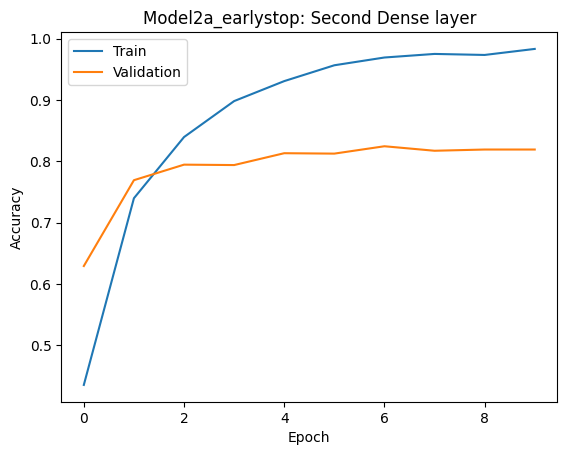

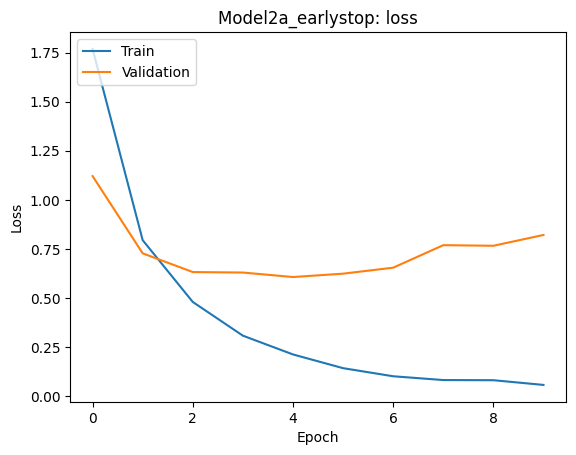

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


# Plot training & validation accuracy values
plt.plot(history2a_earlystop.history['accuracy'])
plt.plot(history2a_earlystop.history['val_accuracy'])
plt.title('Model2a_earlystop: Second Dense layer')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.plot(history2a_earlystop.history['loss'])
plt.plot(history2a_earlystop.history['val_loss'])
plt.title('Model2a_earlystop: loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Model2a stops at epoch 10 after the loss has not decreased since epoch 5.

## L1 Regularization

In [ ]:
# Create a Sequential Model
model3 = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model3.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.001))) #128 = 128 outputs
# Add a second Dense layer
model3.add(keras.layers.Dense(128, activation='relu'))
# Add another Dense layer to serve as the output layer
model3.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

model3.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model3.save_weights("initial_weights.chk")

history3 = model3.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val))


Epoch 1/30
375/375 [==============================] - 6s 14ms/step - loss: 3.0340 - accuracy: 0.3210 - val_loss: 2.4000 - val_accuracy: 0.4213
Epoch 2/30
375/375 [==============================] - 5s 14ms/step - loss: 2.2141 - accuracy: 0.5151 - val_loss: 2.0507 - val_accuracy: 0.5807
Epoch 3/30
375/375 [==============================] - 4s 12ms/step - loss: 1.9222 - accuracy: 0.6211 - val_loss: 1.8964 - val_accuracy: 0.6380
Epoch 4/30
375/375 [==============================] - 4s 10ms/step - loss: 1.7374 - accuracy: 0.6801 - val_loss: 1.7457 - val_accuracy: 0.6960
Epoch 5/30
375/375 [==============================] - 4s 10ms/step - loss: 1.6131 - accuracy: 0.7219 - val_loss: 1.6470 - val_accuracy: 0.7040
Epoch 6/30
375/375 [==============================] - 5s 14ms/step - loss: 1.5268 - accuracy: 0.7427 - val_loss: 1.6310 - val_accuracy: 0.7267
Epoch 7/30
375/375 [==============================] - 4s 12ms/step - loss: 1.4631 - accuracy: 0.7645 - val_loss: 1.5867 - val_accuracy: 0.7360

In [ ]:
model.save('model3.keras')

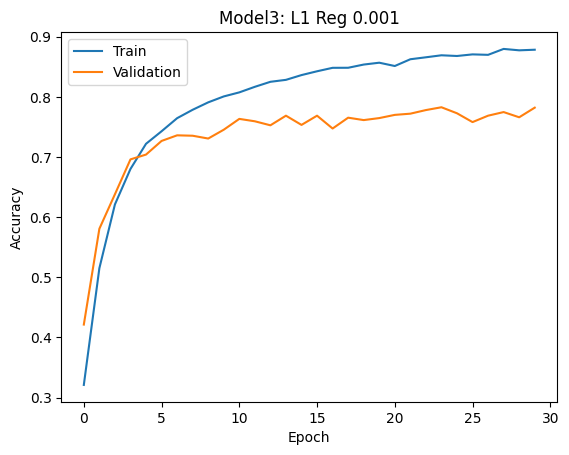

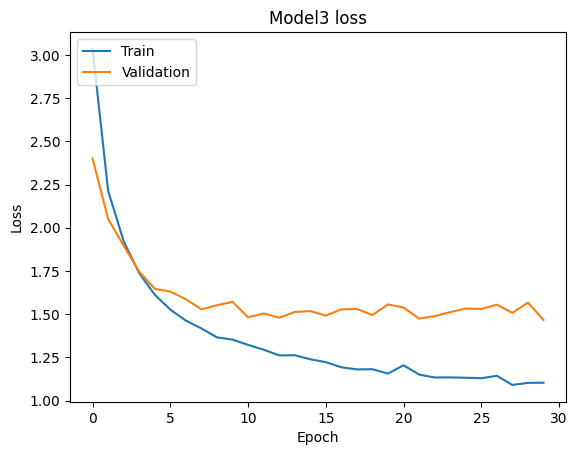

In [ ]:
# Plot training & validation accuracy values
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('Model3: L1 Reg 0.001')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('Model3 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Seems like L1 Regularization has not improved the results. In fact, the loss doubled to 1.50-1.70 while accuracy dropped to below 0.80. I shall try L2 Regularization instead.

## L2 Regularization

In [ ]:

# Create a Sequential Model
model2aL2 = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model2aL2.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))) #128 = 128 outputs
# Add a second Dense layer
model2aL2.add(keras.layers.Dense(64, activation='relu'))
# Add a third Dense layer
model2aL2.add(keras.layers.Dense(64, activation='relu'))

# Add another Dense layer to serve as the output layer
model2aL2.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

model2aL2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model2aL2.save_weights("initial_weights.chk")

history2aL2 = model2aL2.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val))




Epoch 1/30
375/375 [==============================] - 5s 11ms/step - loss: 2.2201 - accuracy: 0.3988 - val_loss: 1.6777 - val_accuracy: 0.5660
Epoch 2/30
375/375 [==============================] - 4s 10ms/step - loss: 1.4759 - accuracy: 0.6472 - val_loss: 1.3714 - val_accuracy: 0.6720
Epoch 3/30
375/375 [==============================] - 5s 13ms/step - loss: 1.2406 - accuracy: 0.7282 - val_loss: 1.2230 - val_accuracy: 0.7360
Epoch 4/30
375/375 [==============================] - 6s 15ms/step - loss: 1.1197 - accuracy: 0.7703 - val_loss: 1.1793 - val_accuracy: 0.7540
Epoch 5/30
375/375 [==============================] - 4s 10ms/step - loss: 1.0268 - accuracy: 0.7997 - val_loss: 1.1916 - val_accuracy: 0.7533
Epoch 6/30
375/375 [==============================] - 5s 14ms/step - loss: 0.9704 - accuracy: 0.8201 - val_loss: 1.0849 - val_accuracy: 0.7940
Epoch 7/30
375/375 [==============================] - 8s 21ms/step - loss: 0.9299 - accuracy: 0.8347 - val_loss: 1.0706 - val_accuracy: 0.8027

In [ ]:
model.save('model2aL2.keras')

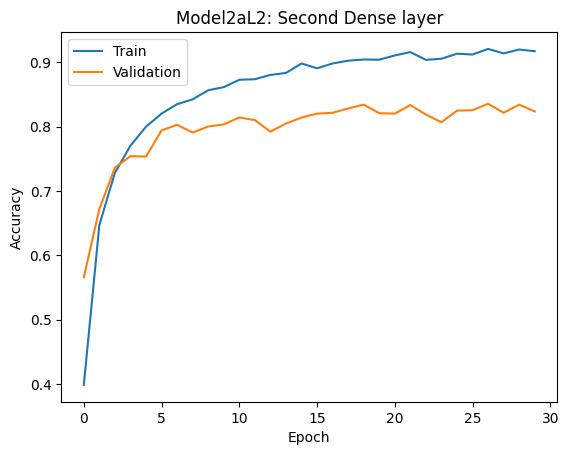

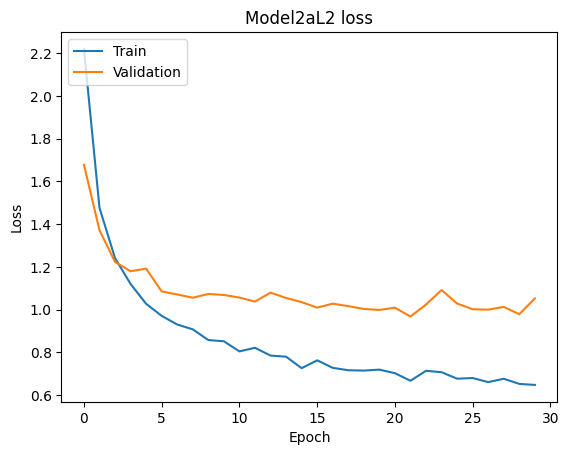

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


# Plot training & validation accuracy values
plt.plot(history2aL2.history['accuracy'])
plt.plot(history2aL2.history['val_accuracy'])
plt.title('Model2aL2: Second Dense layer')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.plot(history2aL2.history['loss'])
plt.plot(history2aL2.history['val_loss'])
plt.title('Model2aL2 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

This model has maintained loss at around 1.0-1.1, but is still higher than Model 2a's loss. Model2aL2 might not be as good.

In [ ]:
# Create a Sequential Model
model4 = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model4.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
# Add a second Dense layer
model4.add(keras.layers.Dense(128, activation='relu'))
# Add another Dense layer to serve as the output layer
model4.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

model4.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model4.save_weights("initial_weights.chk")

history4 = model4.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val))



Epoch 1/30
375/375 [==============================] - 5s 12ms/step - loss: 2.2089 - accuracy: 0.4159 - val_loss: 1.6978 - val_accuracy: 0.5713
Epoch 2/30
375/375 [==============================] - 3s 9ms/step - loss: 1.5332 - accuracy: 0.6339 - val_loss: 1.4377 - val_accuracy: 0.6667
Epoch 3/30
375/375 [==============================] - 4s 9ms/step - loss: 1.3133 - accuracy: 0.7067 - val_loss: 1.2647 - val_accuracy: 0.7227
Epoch 4/30
375/375 [==============================] - 5s 13ms/step - loss: 1.1827 - accuracy: 0.7509 - val_loss: 1.2654 - val_accuracy: 0.7200
Epoch 5/30
375/375 [==============================] - 5s 12ms/step - loss: 1.0999 - accuracy: 0.7801 - val_loss: 1.1248 - val_accuracy: 0.7740
Epoch 6/30
375/375 [==============================] - 4s 9ms/step - loss: 1.0238 - accuracy: 0.8048 - val_loss: 1.1084 - val_accuracy: 0.7787
Epoch 7/30
375/375 [==============================] - 4s 10ms/step - loss: 0.9920 - accuracy: 0.8102 - val_loss: 1.1517 - val_accuracy: 0.7533
Ep

In [ ]:
model.save('model4.keras')

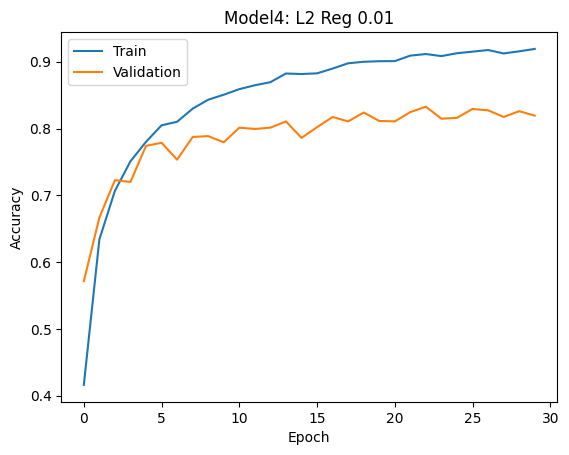

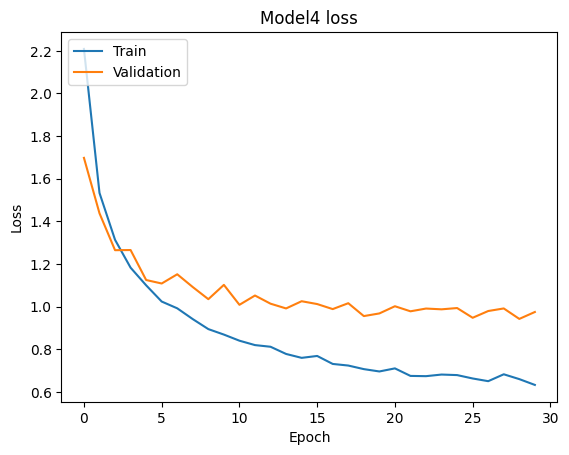

In [ ]:
# Plot training & validation accuracy values
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.title('Model4: L2 Reg 0.01')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.title('Model4 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

L2 regularization in Model 4 performs better than L1 at maintaining accuracy, over Model 3. Its loss at below 1.20 is also better than Model 3's.

# Dropout regularization

In [ ]:
# Create a Sequential Model
model5 = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model5.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu'))
# Add dropout layer
model5.add(tf.keras.layers.Dropout(rate=0.5))
# Add a second Dense layer
model5.add(keras.layers.Dense(128, activation='relu'))
# Add another Dense layer to serve as the output layer
model5.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

model5.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model5.save_weights("initial_weights.chk")
test_loss5, test_acc5 = model5.evaluate(x_val_scaled, y_val)

history5 = model5.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val))



47/47 [==============================] - 0s 3ms/step - loss: 2.7069 - accuracy: 0.0640
loss: 2.706855058670044
accuracy 0.06400000303983688
Epoch 1/30
375/375 [==============================] - 4s 10ms/step - loss: 2.0346 - accuracy: 0.3543 - val_loss: 1.4051 - val_accuracy: 0.5600
Epoch 2/30
375/375 [==============================] - 5s 13ms/step - loss: 1.3157 - accuracy: 0.5787 - val_loss: 1.0035 - val_accuracy: 0.6960
Epoch 3/30
375/375 [==============================] - 6s 15ms/step - loss: 1.0624 - accuracy: 0.6568 - val_loss: 0.8578 - val_accuracy: 0.7493
Epoch 4/30
375/375 [==============================] - 4s 11ms/step - loss: 0.9081 - accuracy: 0.6977 - val_loss: 0.7700 - val_accuracy: 0.7560
Epoch 5/30
375/375 [==============================] - 4s 9ms/step - loss: 0.8126 - accuracy: 0.7324 - val_loss: 0.7233 - val_accuracy: 0.7827
Epoch 6/30
375/375 [==============================] - 3s 9ms/step - loss: 0.7336 - accuracy: 0.7532 - val_loss: 0.6758 - val_accuracy: 0.7947
Epoc

In [ ]:
model.save('model5.keras')

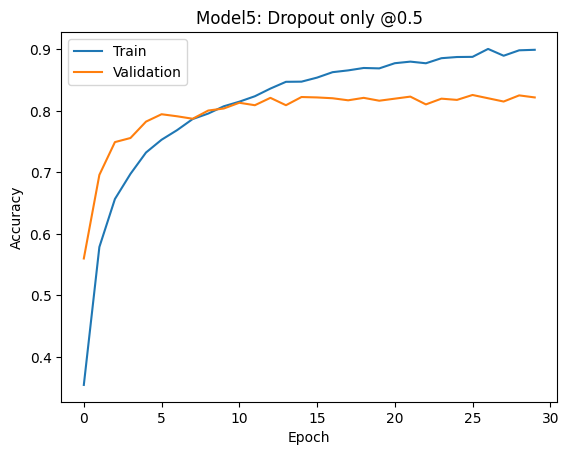

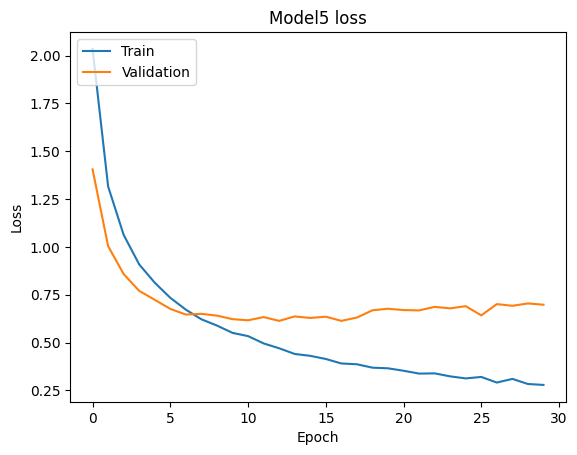

In [ ]:
# Plot training & validation accuracy values
plt.plot(history5.history['accuracy'])
plt.plot(history5.history['val_accuracy'])
plt.title('Model5: Dropout only @0.5')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.plot(history5.history['loss'])
plt.plot(history5.history['val_loss'])
plt.title('Model5 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

The results from Model 5 are very good. Overfitting has been managed and accuracy is high at around 0.8

In [ ]:
# Create a Sequential Model
model7 = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model7.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu')) #128 = 128 outputs
# Add dropout layer
model7.add(tf.keras.layers.Dropout(rate=0.1))

# Add a second Dense layer
model7.add(keras.layers.Dense(64, activation='relu'))
# Add dropout layer
model7.add(tf.keras.layers.Dropout(rate=0.1))

# Add a third Dense layer
model7.add(keras.layers.Dense(64, activation='relu'))
# Add dropout layer
model7.add(tf.keras.layers.Dropout(rate=0.1))

# Add another Dense layer to serve as the output layer
model7.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

model7.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model7.save_weights("initial_weights.chk")

history7 = model7.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val))



Epoch 1/30
375/375 [==============================] - 6s 13ms/step - loss: 1.9482 - accuracy: 0.3772 - val_loss: 1.2118 - val_accuracy: 0.6193
Epoch 2/30
375/375 [==============================] - 5s 14ms/step - loss: 1.0544 - accuracy: 0.6443 - val_loss: 0.8390 - val_accuracy: 0.7367
Epoch 3/30
375/375 [==============================] - 4s 11ms/step - loss: 0.7491 - accuracy: 0.7426 - val_loss: 0.6710 - val_accuracy: 0.7873
Epoch 4/30
375/375 [==============================] - 3s 9ms/step - loss: 0.5759 - accuracy: 0.7993 - val_loss: 0.6014 - val_accuracy: 0.8087
Epoch 5/30
375/375 [==============================] - 5s 13ms/step - loss: 0.4629 - accuracy: 0.8365 - val_loss: 0.5833 - val_accuracy: 0.8033
Epoch 6/30
375/375 [==============================] - 5s 12ms/step - loss: 0.3840 - accuracy: 0.8652 - val_loss: 0.5434 - val_accuracy: 0.8220
Epoch 7/30
375/375 [==============================] - 4s 9ms/step - loss: 0.3253 - accuracy: 0.8829 - val_loss: 0.5751 - val_accuracy: 0.8247
E

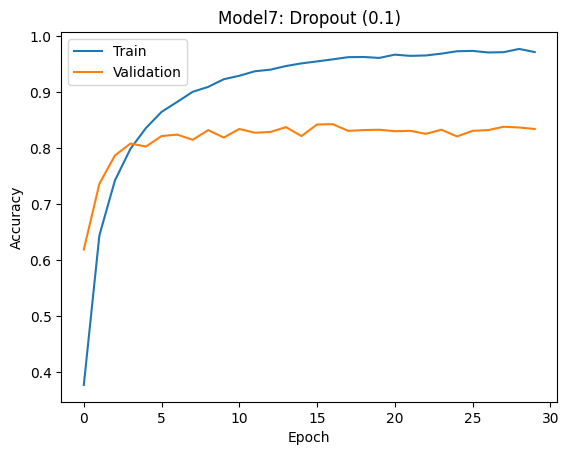

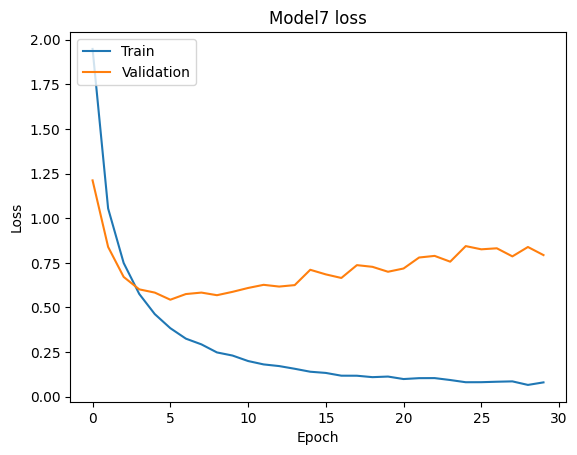

In [ ]:
# Plot training & validation accuracy values
plt.plot(history7.history['accuracy'])
plt.plot(history7.history['val_accuracy'])
plt.title('Model7: Dropout (0.1)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.plot(history7.history['loss'])
plt.plot(history7.history['val_loss'])
plt.title('Model7 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Early Stopping

In [ ]:
# Import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

# Create a Sequential Model
model6 = keras.Sequential()
# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model6.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu'))
# Add dropout layer
model6.add(tf.keras.layers.Dropout(rate=0.4))
# Add a second Dense layer
model6.add(keras.layers.Dense(128, activation='relu'))
# Add  second dropout layer
model6.add(tf.keras.layers.Dropout(rate=0.4))
# Add another Dense layer to serve as the output layer
model6.add(keras.layers.Dense(15, activation='softmax')) #Output 15 units for 15 classes

model6.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min', restore_best_weights=True)

# Save initial weights
model6.save_weights("initial_weights.chk")

# Fit the model with early stopping
history6 = model6.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val), callbacks=[early_stopping])


Epoch 1/30
375/375 [==============================] - 6s 15ms/step - loss: 2.1507 - accuracy: 0.3078 - val_loss: 1.4684 - val_accuracy: 0.5507
Epoch 2/30
375/375 [==============================] - 3s 9ms/step - loss: 1.4086 - accuracy: 0.5443 - val_loss: 1.0442 - val_accuracy: 0.6727
Epoch 3/30
375/375 [==============================] - 3s 9ms/step - loss: 1.1051 - accuracy: 0.6342 - val_loss: 0.8628 - val_accuracy: 0.7353
Epoch 4/30
375/375 [==============================] - 5s 13ms/step - loss: 0.9472 - accuracy: 0.6840 - val_loss: 0.7683 - val_accuracy: 0.7633
Epoch 5/30
375/375 [==============================] - 6s 16ms/step - loss: 0.8350 - accuracy: 0.7189 - val_loss: 0.7026 - val_accuracy: 0.7873
Epoch 6/30
375/375 [==============================] - 6s 15ms/step - loss: 0.7346 - accuracy: 0.7521 - val_loss: 0.6744 - val_accuracy: 0.7760
Epoch 7/30
375/375 [==============================] - 3s 9ms/step - loss: 0.6810 - accuracy: 0.7671 - val_loss: 0.6342 - val_accuracy: 0.7887
Ep

In [ ]:
model.save('model6.keras')

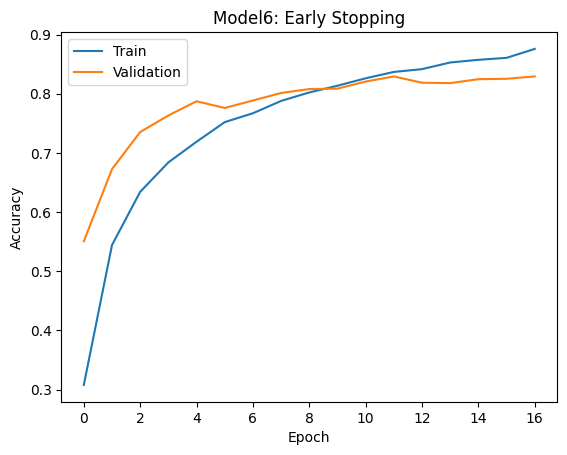

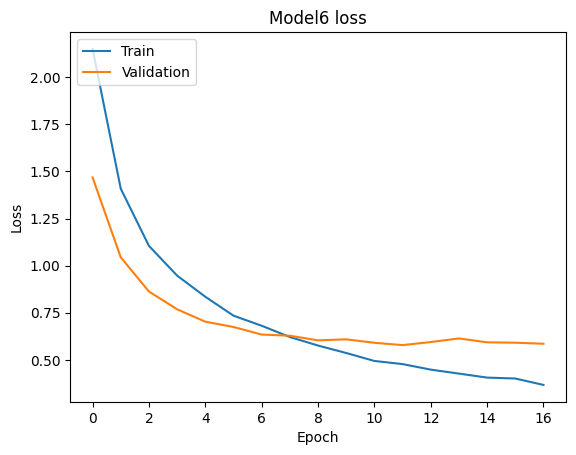

In [ ]:
# Plot training & validation accuracy values
plt.plot(history6.history['accuracy'])
plt.plot(history6.history['val_accuracy'])
plt.title('Model6: Early Stopping')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.plot(history6.history['loss'])
plt.plot(history6.history['val_loss'])
plt.title('Model6 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Model 6's results are as good as model 5's. Its loss drops to below 0.6 and accuracy is around 0.81

# Base model but with rmsprop as optimizer
## Here I will try out another optimizer in rmsprop

In [ ]:
# Create a Sequential Model
model = keras.Sequential()

# Add a Dense hidden layer to it. A Dense layer will be a fully-connected layer
model.add(keras.layers.Dense(128, input_shape=(4096,), activation='relu'))

# Add another Dense layer to serve as the output layer
model.add(keras.layers.Dense(15, activation='softmax'))  # Output 15 units for 15 classes

# Change the optimizer to RMSprop
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_val_scaled, y_val)
print("loss:", test_loss)
print("accuracy:", test_acc)

# Fit the model
history_rmsprop = model.fit(x_train_scaled, y_train, epochs=30, validation_data=(x_val_scaled, y_val))


47/47 [==============================] - 1s 5ms/step - loss: 2.7163 - accuracy: 0.0647
loss: 2.716296434402466
accuracy: 0.06466666609048843
Epoch 1/30
375/375 [==============================] - 4s 8ms/step - loss: 1.9998 - accuracy: 0.4175 - val_loss: 1.6137 - val_accuracy: 0.5313
Epoch 2/30
375/375 [==============================] - 3s 8ms/step - loss: 1.3579 - accuracy: 0.6160 - val_loss: 1.2767 - val_accuracy: 0.6273
Epoch 3/30
375/375 [==============================] - 3s 8ms/step - loss: 1.0106 - accuracy: 0.7158 - val_loss: 1.0484 - val_accuracy: 0.6887
Epoch 4/30
375/375 [==============================] - 4s 9ms/step - loss: 0.7781 - accuracy: 0.7864 - val_loss: 0.9003 - val_accuracy: 0.7387
Epoch 5/30
375/375 [==============================] - 4s 11ms/step - loss: 0.6185 - accuracy: 0.8317 - val_loss: 0.8168 - val_accuracy: 0.7500
Epoch 6/30
375/375 [==============================] - 3s 9ms/step - loss: 0.5050 - accuracy: 0.8631 - val_loss: 0.7568 - val_accuracy: 0.7700
Epoch 

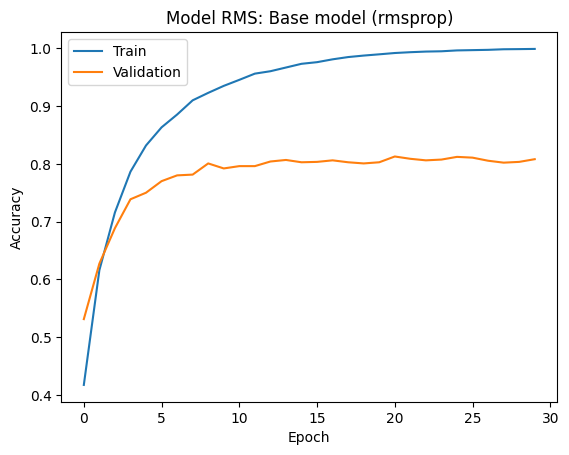

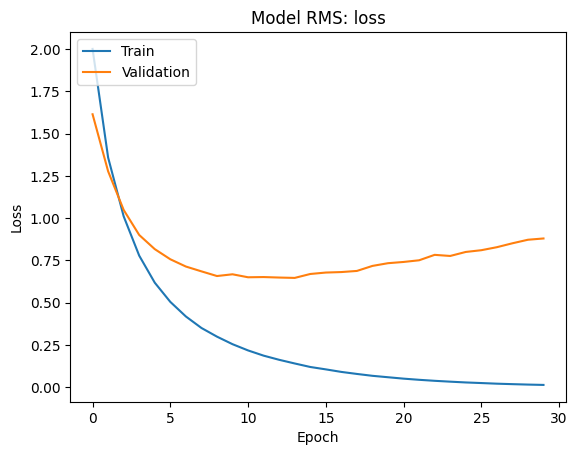

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


# Plot training & validation accuracy values
plt.plot(history_rmsprop.history['accuracy'])
plt.plot(history_rmsprop.history['val_accuracy'])
plt.title('Model RMS: Base model (rmsprop)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history_rmsprop.history['loss'])
plt.plot(history_rmsprop.history['val_loss'])
plt.title('Model RMS: loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

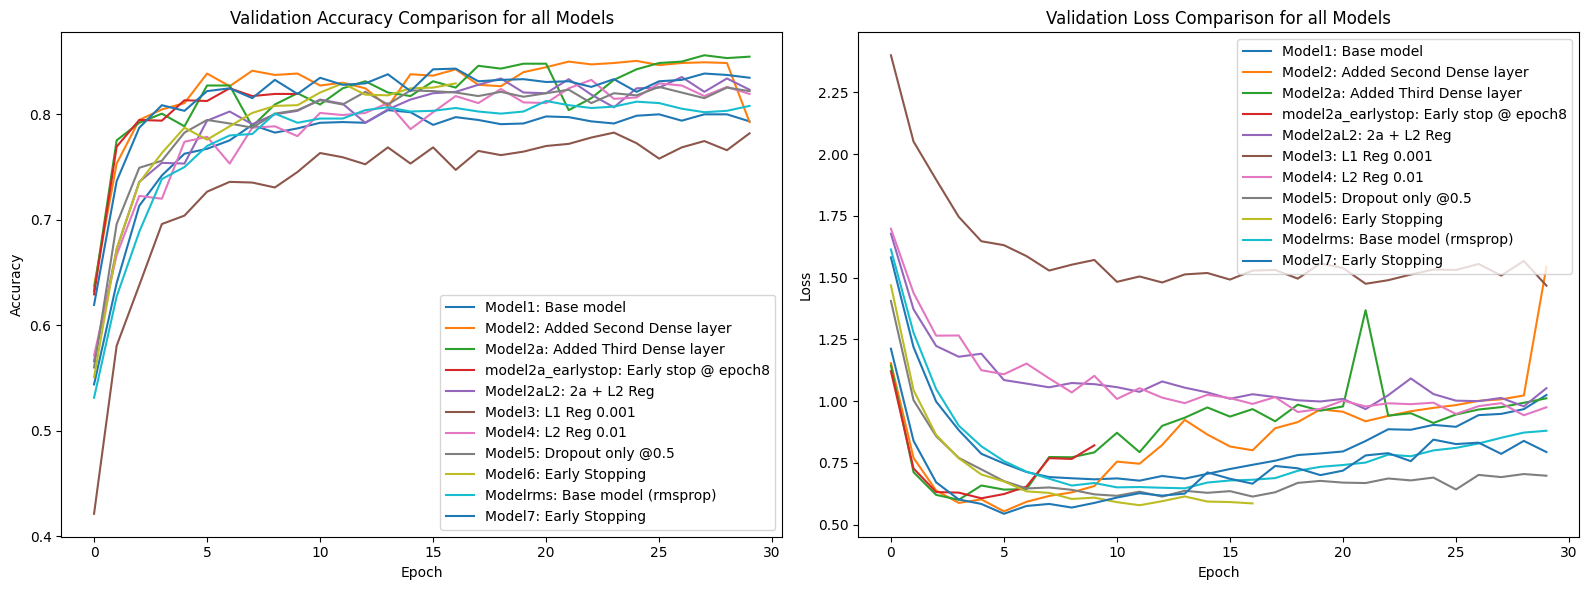

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have history objects for each model

# Set up the subplots
plt.figure(figsize=(16, 6))

# Plot training & validation accuracy values for Model Comparison
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Model1: Base model')
plt.plot(history2.history['val_accuracy'], label='Model2: Added Second Dense layer')
plt.plot(history2a.history['val_accuracy'], label='Model2a: Added Third Dense layer')
plt.plot(history2a_earlystop.history['val_accuracy'], label='model2a_earlystop: Early stop @ epoch8')
plt.plot(history2aL2.history['val_accuracy'], label='Model2aL2: 2a + L2 Reg')
plt.plot(history3.history['val_accuracy'], label='Model3: L1 Reg 0.001')
plt.plot(history4.history['val_accuracy'], label='Model4: L2 Reg 0.01')
plt.plot(history5.history['val_accuracy'], label='Model5: Dropout only @0.5')
plt.plot(history6.history['val_accuracy'], label='Model6: Early Stopping')
plt.plot(history_rmsprop.history['val_accuracy'], label='Modelrms: Base model (rmsprop)')
plt.plot(history7.history['val_accuracy'], label='Model7: Early Stopping')
plt.title('Validation Accuracy Comparison for all Models')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss values for Model Comparison
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Model1: Base model')
plt.plot(history2.history['val_loss'], label='Model2: Added Second Dense layer')
plt.plot(history2a.history['val_loss'], label='Model2a: Added Third Dense layer')
plt.plot(history2a_earlystop.history['val_loss'], label='model2a_earlystop: Early stop @ epoch8')
plt.plot(history2aL2.history['val_loss'], label='Model2aL2: 2a + L2 Reg')
plt.plot(history3.history['val_loss'], label='Model3: L1 Reg 0.001')
plt.plot(history4.history['val_loss'], label='Model4: L2 Reg 0.01')
plt.plot(history5.history['val_loss'], label='Model5: Dropout only @0.5')
plt.plot(history6.history['val_loss'], label='Model6: Early Stopping')
plt.plot(history_rmsprop.history['val_loss'], label='Modelrms: Base model (rmsprop)')
plt.plot(history7.history['val_loss'], label='Model7: Early Stopping')
plt.title('Validation Loss Comparison for all Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plots
plt.show()


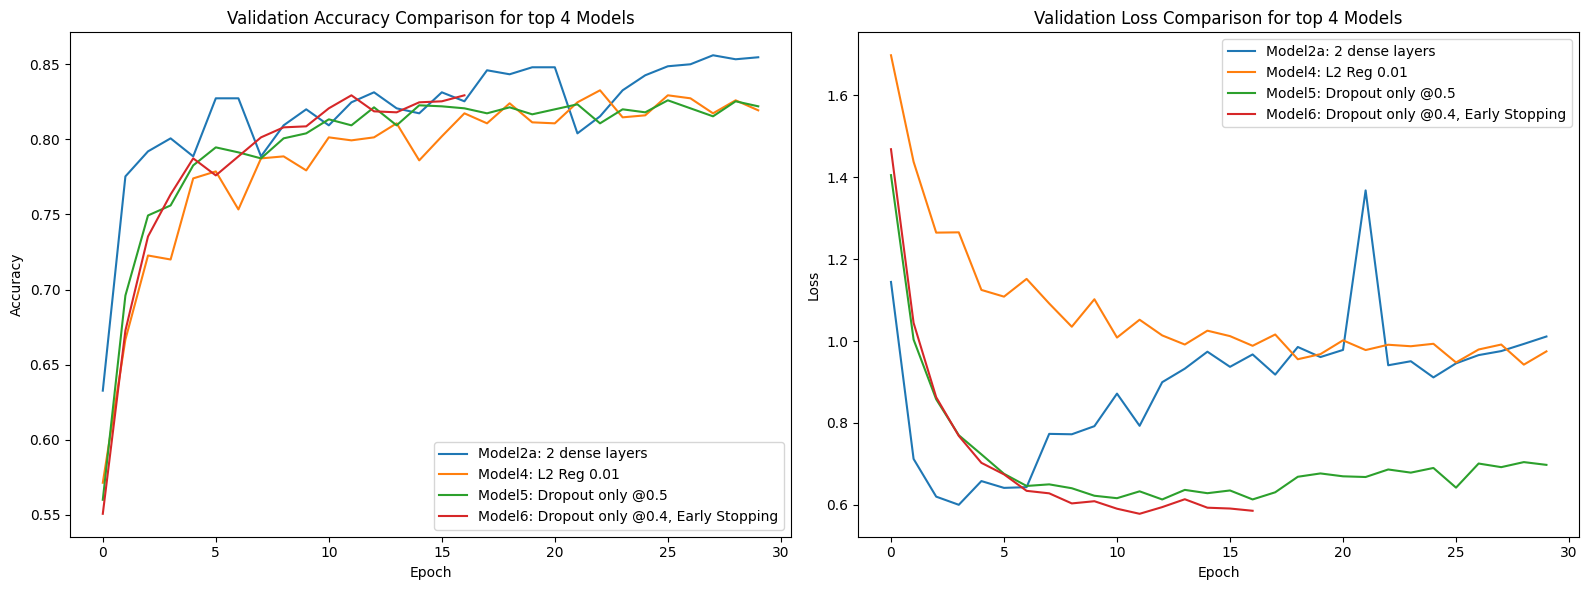

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have history objects for each model

plt.figure(figsize=(16, 6))

# Plot training & validation accuracy values for Model Comparison
plt.subplot(1, 2, 1)
plt.plot(history2a.history['val_accuracy'], label='Model2a: 2 dense layers')
plt.plot(history4.history['val_accuracy'], label='Model4: L2 Reg 0.01')
plt.plot(history5.history['val_accuracy'], label='Model5: Dropout only @0.5')
plt.plot(history6.history['val_accuracy'], label='Model6: Dropout only @0.4, Early Stopping')

# Set plot properties
plt.title('Validation Accuracy Comparison for top 4 Models')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')


plt.subplot(1, 2, 2)
plt.plot(history2a.history['val_loss'], label='Model2a: 2 dense layers')
plt.plot(history4.history['val_loss'], label='Model4: L2 Reg 0.01')
plt.plot(history5.history['val_loss'], label='Model5: Dropout only @0.5')
plt.plot(history6.history['val_loss'], label='Model6: Dropout only @0.4, Early Stopping')

# Set plot properties
plt.title('Validation Loss Comparison for top 4 Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plots
plt.show()


# Selection of model
Based on the comparison plots of the top 4 models above, I have selected the Model 6 as the final model to deploy on the testing dataset. After comparing the test loss and accuracies of the 4 models, Model 6 hits the sweet spot.

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model2a.evaluate(x_test_scaled, y_test)

# Print the evaluation results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


47/47 [==============================] - 0s 3ms/step - loss: 0.9874 - accuracy: 0.8533
Test Loss: 0.9873518943786621
Test Accuracy: 0.8533333539962769


In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model4.evaluate(x_test_scaled, y_test)

# Print the evaluation results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


47/47 [==============================] - 0s 4ms/step - loss: 0.9899 - accuracy: 0.8227
Test Loss: 0.989852786064148
Test Accuracy: 0.8226666450500488


In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model5.evaluate(x_test_scaled, y_test)

# Print the evaluation results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


47/47 [==============================] - 0s 4ms/step - loss: 0.7001 - accuracy: 0.8153
Test Loss: 0.7000766396522522
Test Accuracy: 0.8153333067893982


In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model6.evaluate(x_test_scaled, y_test)

# Print the evaluation results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


47/47 [==============================] - 1s 13ms/step - loss: 0.5747 - accuracy: 0.8253
Test Loss: 0.5747011303901672
Test Accuracy: 0.8253333568572998


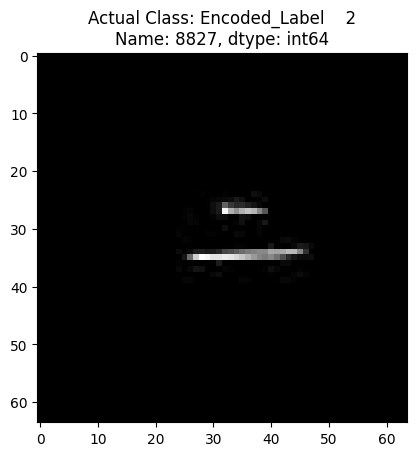

1/1 [==============================] - 0s 26ms/step
Predicted Class: 2
Actual Class: Encoded_Label    2
Name: 8827, dtype: int64




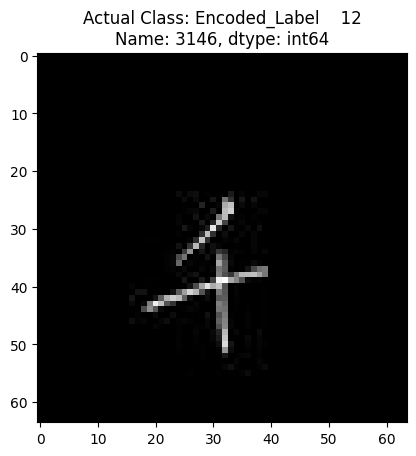

1/1 [==============================] - 0s 28ms/step
Predicted Class: 12
Actual Class: Encoded_Label    12
Name: 3146, dtype: int64




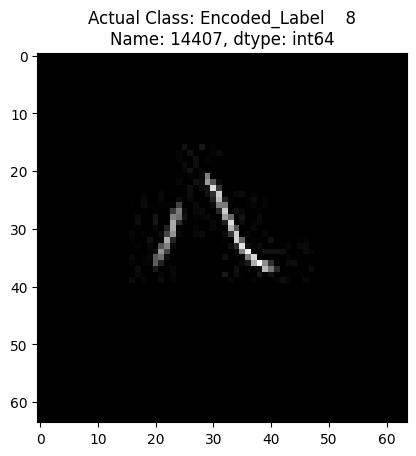

1/1 [==============================] - 0s 35ms/step
Predicted Class: 8
Actual Class: Encoded_Label    8
Name: 14407, dtype: int64




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Number of sets to display
num_sets = 3

for _ in range(num_sets):
    # Select a random index from the test set
    random_index = np.random.randint(0, len(x_test_scaled))

    # Get the random test image and its corresponding label
    random_image = x_test_scaled.iloc[random_index].values
    actual_label = y_test.iloc[random_index]

    # Reshape the image to (64, 64)
    random_image_reshaped = random_image.reshape((64, 64))

    # Display the image
    plt.imshow(random_image_reshaped, cmap='gray')
    plt.title('Actual Class: {}'.format(actual_label))
    plt.show()

    # Expand dimensions to match model input shape
    random_image_expanded = np.expand_dims(random_image, axis=0)

    # Get the model's predicted probabilities
    predicted_probabilities = model6.predict(random_image_expanded)

    # Get the predicted class label
    predicted_class = np.argmax(predicted_probabilities)

    # Print the predicted class and actual class
    print("Predicted Class: {}".format(predicted_class))
    print("Actual Class: {}".format(actual_label))
    print("\n" + "="*40 + "\n")  # Add a separator for clarity


In [ ]:
# Predict on the test set
predictions = model6.predict(x_test_scaled)

# Get the predicted classes
predicted_classes = predictions.argmax(axis=1)

# Convert y_test column to a 1D NumPy array
y_test_flattened = y_test['Encoded_Label'].values.flatten()

# Create a DataFrame with actual and predicted classes
model6_results = pd.DataFrame({'Actual_Class': y_test_flattened, 'Predicted_Class': predicted_classes})


# Display the DataFrame
print(model6_results)


47/47 [==============================] - 0s 5ms/step
      Actual_Class  Predicted_Class
0               11               12
1                3                3
2                3                3
3                2                2
4                7                7
...            ...              ...
1495             7                7
1496            11               11
1497             0                0
1498             6                6
1499             7               10

[1500 rows x 2 columns]


In [ ]:
wrong_predictions = model6_results[model6_results['Actual_Class'] != model6_results['Predicted_Class']]

# Display the filtered DataFrame
print(wrong_predictions)


      Actual_Class  Predicted_Class
0               11               12
7               11                0
10               3                2
12               5               11
13               2                1
...            ...              ...
1453             0               11
1464             8               10
1479             6                7
1482             3                2
1499             7               10

[262 rows x 2 columns]


11    29
12    29
9     25
14    22
2     20
3     19
6     19
13    18
5     17
7     15
4     13
10    12
8     12
0      8
1      4
Name: Actual_Class, dtype: int64


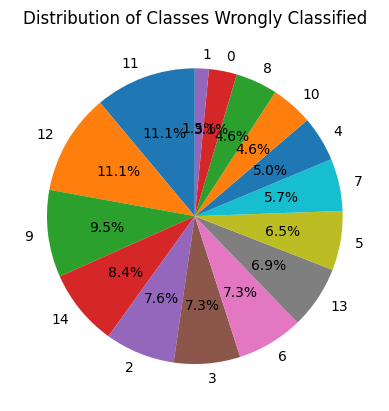

In [ ]:
import matplotlib.pyplot as plt

actual_class_counts = wrong_predictions['Actual_Class'].value_counts()

print(actual_class_counts)

plt.pie(actual_class_counts, labels=actual_class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Classes Wrongly Classified')
plt.show()

From the above visualization, it looks like the label '11', aka the chinese numeral 千 is the character that is misclassified the most, as well as the label '12' aka 万. The only character that has the fewest incorrect predictions is the chinese character 一, or the number 1.

# Deep Learning vs Classical Machine Learning

It is very common to compare deep learning algorithms and classical machine learning algorithms. On first glance, both do share some similarities but in practice, their usefulness and operation can be very different.

## Introduction of each model

Deep learning models replicate the way the neurons in the human brain works, where neurons are interconnected. The neurons can be arranged in hidden layers, where the first layer process simple features of the data and subsequent layers process complex data.

Classical machine learning is more of a rules-based model. The user has to lay down the rules, like deciding which algorithm (decision tree or SVM) to run. Feature engineering is also very important before the model can generate good results.

As a result, deep learning models can process huge amounts of complex data as there can be multiple layers of interconnected neurons learning from the features of the data.

## Feature Representation

Deep learning models can work on unstructured data like images, text and audio. They can automatically learn features from raw data.

For machine learning, it works well if the features are well-defined. Otherwise, feature engineering has to be done.

## Data Size and Training Time

Deep learning models can work on extremely large datasets. For complex models, however, it can be time consuming if the hardware or GPU is not powerful enough.

Conversely, machine learning models generally work on smaller datasets and are worked in sections sequentially. Hence algorithms run faster and are less computationally intensive.

## Interpretability of model

Deep learning models are sometimes labelled as 'black boxes' because it is very challenging to understand how the model works in the interconnected neurons in the hidden layers. On the other hand, machine learning models can be interpreted more easily as the mechanism is more 'visible' as the user implements the model in sections.

## Use cases

Deep learning models can be used in image recognition (Convolutional neural network) and natural language processing (recurrent neural network). Machine learning use cases are quite different, like prediction of housing prices (logistic regression), fraud detection (decision trees) and customer segmentation (K-NN).

## Conclusion

Deep learning and machine learning models can differ in their respective use cases, while will lead to the differences in size and complexity of the dataset. As such, resource requirements can differ. It all depends on the user's requirements and the capabilities of the hardware available.